In [2]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

from fastai import *
from fastai.vision import *

In [2]:
bs = 64

In [3]:
path = Path(Path.home()/'tutorials/data/distracted-driver/'); path

PosixPath('/home/jupyter/tutorials/data/distracted-driver')

In [4]:
path.ls()

[PosixPath('/home/jupyter/tutorials/data/distracted-driver/driver_imgs_list.csv'),
 PosixPath('/home/jupyter/tutorials/data/distracted-driver/models'),
 PosixPath('/home/jupyter/tutorials/data/distracted-driver/test'),
 PosixPath('/home/jupyter/tutorials/data/distracted-driver/valid'),
 PosixPath('/home/jupyter/tutorials/data/distracted-driver/train'),
 PosixPath('/home/jupyter/tutorials/data/distracted-driver/sample_submission.csv')]

In [5]:
img_list = pd.read_csv(path/'driver_imgs_list.csv')

In [6]:
img_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22424 entries, 0 to 22423
Data columns (total 3 columns):
subject      22424 non-null object
classname    22424 non-null object
img          22424 non-null object
dtypes: object(3)
memory usage: 525.6+ KB


In [7]:
img_list.head()

,subject,classname,img
0,p002,c0,img_44733.jpg
1,p002,c0,img_72999.jpg
2,p002,c0,img_25094.jpg
3,p002,c0,img_69092.jpg
4,p002,c0,img_92629.jpg


In [8]:
# checking the training folder
(path/'train').ls()

[PosixPath('/home/jupyter/tutorials/data/distracted-driver/train/c8'),
 PosixPath('/home/jupyter/tutorials/data/distracted-driver/train/c9'),
 PosixPath('/home/jupyter/tutorials/data/distracted-driver/train/c1'),
 PosixPath('/home/jupyter/tutorials/data/distracted-driver/train/c5'),
 PosixPath('/home/jupyter/tutorials/data/distracted-driver/train/c7'),
 PosixPath('/home/jupyter/tutorials/data/distracted-driver/train/c6'),
 PosixPath('/home/jupyter/tutorials/data/distracted-driver/train/c2'),
 PosixPath('/home/jupyter/tutorials/data/distracted-driver/train/c3'),
 PosixPath('/home/jupyter/tutorials/data/distracted-driver/train/c0'),
 PosixPath('/home/jupyter/tutorials/data/distracted-driver/train/c4')]

In [9]:
# checking distribution of classes
data_dist = np.array([[int(str(i)[-1:]),len(i.ls())] for i in (path/'train').ls()])
data_dist

array([[   8, 1911],
       [   9, 2129],
       [   1, 2267],
       [   5, 2312],
       [   7, 2002],
       [   6, 2325],
       [   2, 2317],
       [   3, 2346],
       [   0, 2489],
       [   4, 2326]])

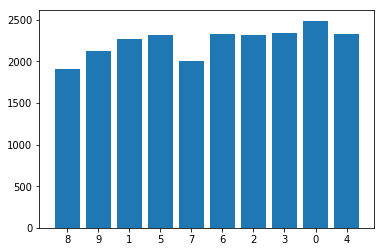

In [10]:
plt.bar(np.arange(len(data_dist)),
        data_dist[:,1],
        tick_label=data_dist[:,0]);

In [40]:
# validation data is not avaialble. Needs to be created

if os.path.isdir(path/'valid'):
    print('Validation data available.')
else:
    print('Creating validation data.')
    valid_ratio = 0.1
    moved_files = {}

    for f in (path/'train').ls():
        temp = []
        for i in f.ls():
            if random.random()<=valid_ratio:
                os.rename(str(i), str(i).replace('train','valid'))
                temp.append(str(i))
        moved_files[str(f)[-2:]]=temp
    
    mf_summ = np.array([[int(k[-1]),len(v)] for k,v in moved_files.items()])
    print('Folders with >.02 variance',
          (((mf_summ[:,1]/data_dist[:,1])-.1)>.02).sum())

Validation data available.


In [5]:
train_dist = np.array([[int(str(i)[-1:]),
                    len(i.ls())] for i in (path/'train').ls()])
valid_dist = np.array([[int(str(i)[-1:]),
                    len(i.ls())] for i in (path/'valid').ls()])

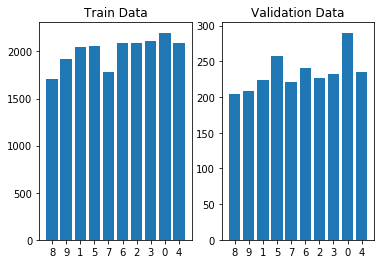

In [51]:
plt.subplot(121)
plt.bar(np.arange(len(train_dist)),
        train_dist[:,1],
        tick_label=train_dist[:,0]);
plt.title('Train Data')

plt.subplot(122)
plt.bar(np.arange(len(valid_dist)),
        valid_dist[:,1],
        tick_label=valid_dist[:,0]);
plt.title('Validation Data');


In [55]:
doc(get_transforms)

In [77]:
data = ImageDataBunch.from_folder(path, ds_tfms = get_transforms(), size=224,
                                  bs = bs).normalize(imagenet_stats)

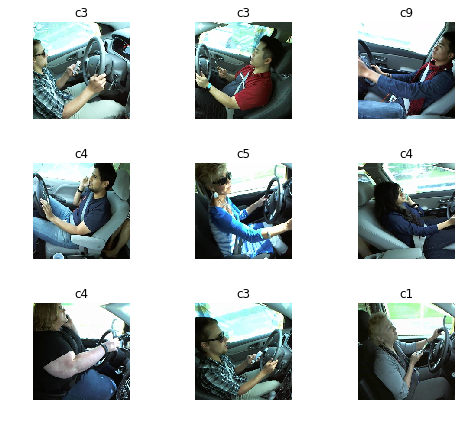

In [78]:
data.show_batch(3, figsize=(7,6))

In [79]:
data.classes

['c8', 'c9', 'c1', 'c5', 'c7', 'c6', 'c2', 'c3', 'c0', 'c4']

In [80]:
len(data.classes)==data.c

True

# Training

In [60]:
doc(create_cnn)

In [83]:
learn = create_cnn(data, models.resnet34, metrics=error_rate)

In [84]:
learn.fit_one_cycle(4)

Total time: 06:35
epoch  train_loss  valid_loss  error_rate
1      0.510843    0.204150    0.058144    (01:40)
2      0.218147    0.094133    0.025224    (01:38)
3      0.136034    0.060623    0.016246    (01:38)
4      0.104879    0.050299    0.014964    (01:38)



In [86]:
learn.save('stage-1')

In [87]:
interp = ClassificationInterpretation.from_learner(learn)

In [90]:
interp.top_losses()

(tensor([9.6931, 8.5884, 7.0452,  ..., -0.0000, -0.0000, -0.0000]),
 tensor([ 924, 2087,  810,  ...,  842, 1784,  655]))

In [93]:
losses,idxs = interp.top_losses()

len(data.valid_ds)==len(losses)==len(idxs)

True

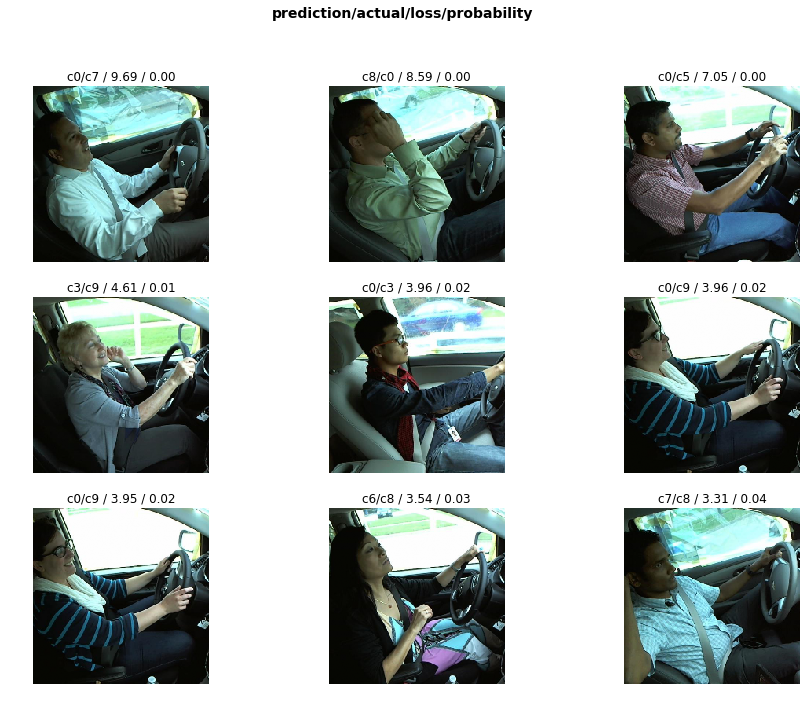

In [94]:
interp.plot_top_losses(9, figsize=(15,11))

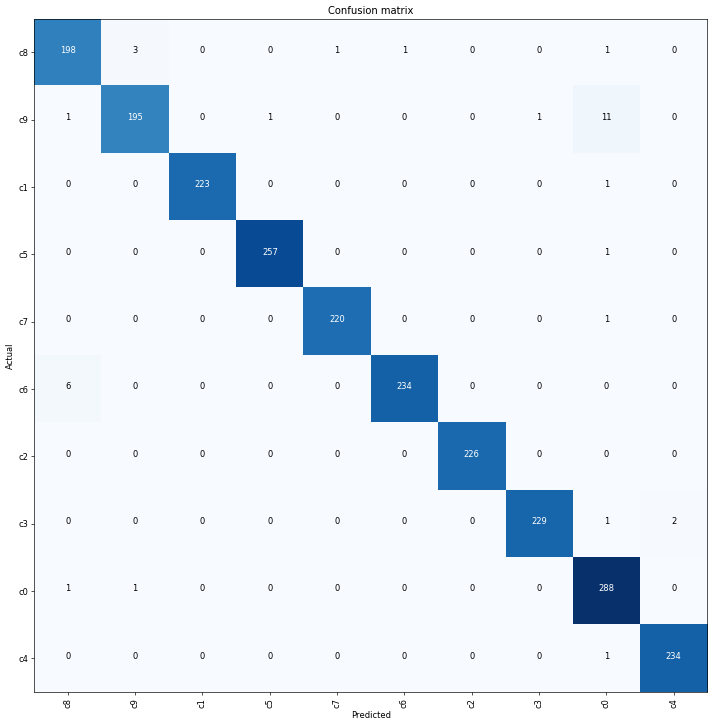

In [95]:
interp.plot_confusion_matrix(figsize=(12,12), dpi=60)

In [96]:
interp.most_confused(min_val=2)

[('c9', 'c0', 11), ('c6', 'c8', 6), ('c8', 'c9', 3)]

## Finetunning

In [97]:
learn.unfreeze()

In [98]:
learn.fit_one_cycle(1)

Total time: 02:08
epoch  train_loss  valid_loss  error_rate
1      0.114545    0.056507    0.016246    (02:08)



In [100]:
learn.load('stage-1');

In [101]:
learn.lr_find()

LR Finder is complete, type {learner_name}.recorder.plot() to see the graph.


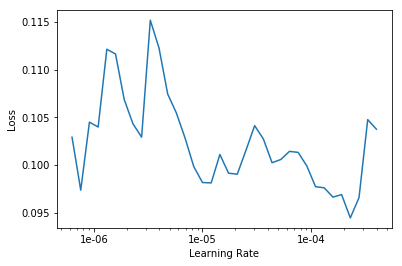

In [102]:
learn.recorder.plot()